# 11 - Visualization and Reporting

Theme: Cameroonian International Migration Trends (2015-2024): Destinations, Entry Reasons and Post-Arrival Trajectories Across Available Reference Years.

This notebook creates final portfolio-ready PNG charts in `outputs/figures/`.

The charts use the analytical master tables created in notebook 09. Q3 charts use Eurostat only for the main visualizations.


## Methodological Positioning

The project does not aim to measure the causal effect of Covid-19. The year 2020 is treated as a contextual reference point when relevant, while the analysis focuses on trends across available reference years. The `period` field is an operational grouping used to structure comparisons across the available data period, not a causal Covid-19 measurement.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


In [2]:
PROJECT_ROOT = Path('..')

ANALYTICAL_PATH = PROJECT_ROOT / 'data' / 'processed' / 'analytical'
FIGURES_PATH = PROJECT_ROOT / 'outputs' / 'figures'

FIGURES_PATH.mkdir(parents=True, exist_ok=True)
period_order = ['pre_covid', 'covid', 'post_covid']


In [3]:
def prepare_table(df):
    """Prepare analytical tables for plotting without changing source files."""
    df = df.copy()
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    df['value'] = pd.to_numeric(df['value'], errors='coerce').fillna(0)

    for col in ['source', 'destination_country', 'period', 'measure_type', 'reason']:
        if col in df.columns:
            df[col] = df[col].astype('string').str.strip()

    return df


def save_figure(file_name):
    """Save the current Matplotlib figure as a high-resolution PNG."""
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / file_name, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


In [4]:
destinations = prepare_table(pd.read_csv(ANALYTICAL_PATH / 'destinations_master.csv'))
entry_reasons = prepare_table(pd.read_csv(ANALYTICAL_PATH / 'entry_reasons_master.csv'))
post_arrival = prepare_table(pd.read_csv(ANALYTICAL_PATH / 'post_arrival_master.csv'))

undesa_destinations = destinations[
    (destinations['source'].str.lower() == 'undesa')
    & (destinations['measure_type'].str.lower() == 'stock')
].copy()

eurostat_entry = entry_reasons[
    (entry_reasons['source'].str.lower() == 'eurostat')
    & (entry_reasons['measure_type'].str.lower() == 'permit')
].copy()

eurostat_post_arrival = post_arrival[
    post_arrival['source'].str.lower() == 'eurostat'
].copy()


## Q1 - Destination Charts Across Reference Years


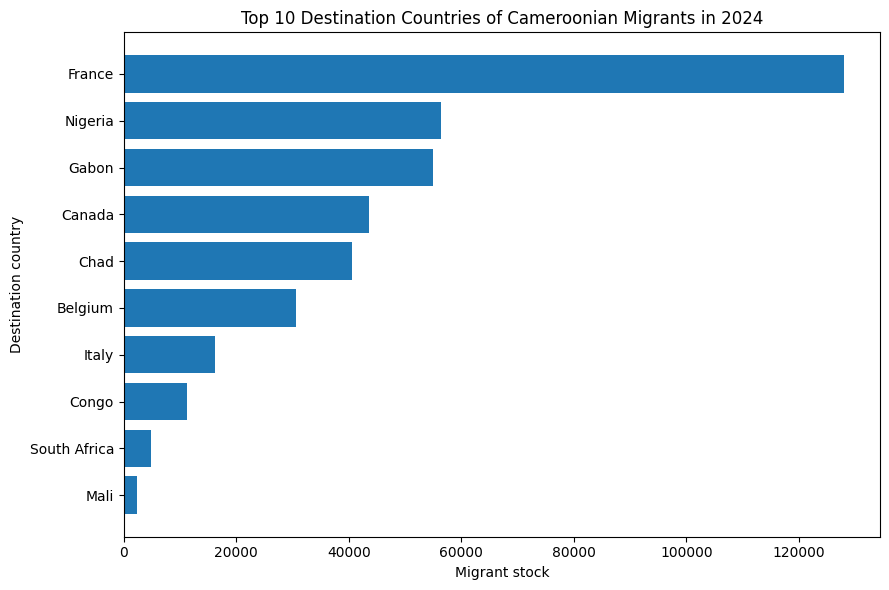

In [5]:
top_2024 = (
    undesa_destinations[undesa_destinations['year'] == 2024]
    .groupby('destination_country', as_index=False)['value']
    .sum()
    .sort_values('value', ascending=False)
    .head(10)
    .sort_values('value')
)

plt.figure(figsize=(9, 6))
plt.barh(top_2024['destination_country'], top_2024['value'])
plt.title('Top 10 Destination Countries of Cameroonian Migrants in 2024')
plt.xlabel('Migrant stock')
plt.ylabel('Destination country')
save_figure('q1_top_10_destinations_2024.png')


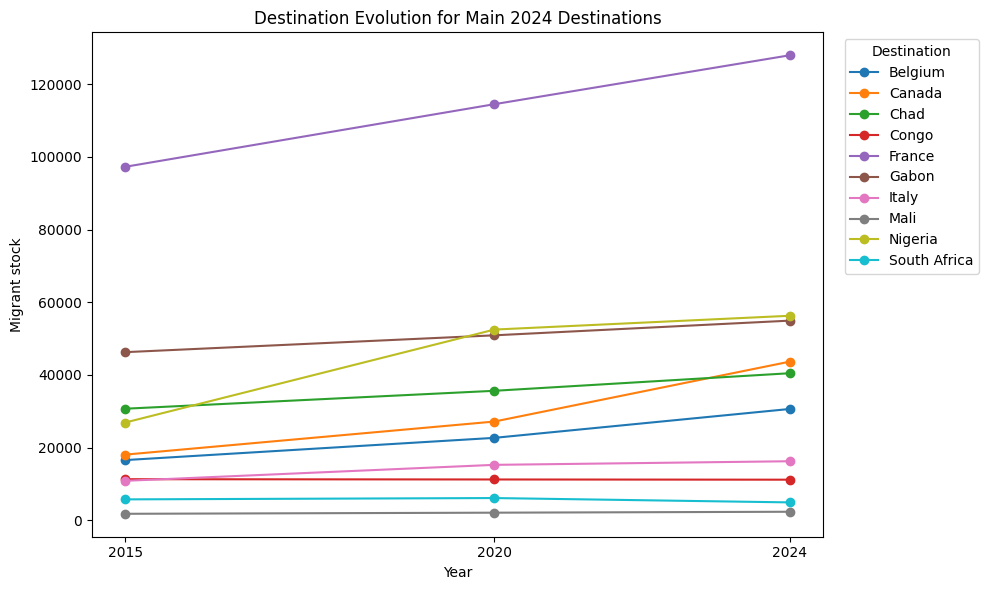

In [6]:
top_countries_2024 = top_2024['destination_country'].tolist()
destination_trends = (
    undesa_destinations[
        undesa_destinations['destination_country'].isin(top_countries_2024)
        & undesa_destinations['year'].isin([2015, 2020, 2024])
    ]
    .groupby(['year', 'destination_country'], as_index=False)['value']
    .sum()
    .pivot(index='year', columns='destination_country', values='value')
    .sort_index()
)

plt.figure(figsize=(10, 6))
for country in destination_trends.columns:
    plt.plot(destination_trends.index, destination_trends[country], marker='o', label=country)
plt.title('Destination Evolution for Main 2024 Destinations')
plt.xlabel('Year')
plt.ylabel('Migrant stock')
plt.xticks([2015, 2020, 2024])
plt.legend(title='Destination', bbox_to_anchor=(1.02, 1), loc='upper left')
save_figure('q1_destination_evolution_2015_2020_2024.png')


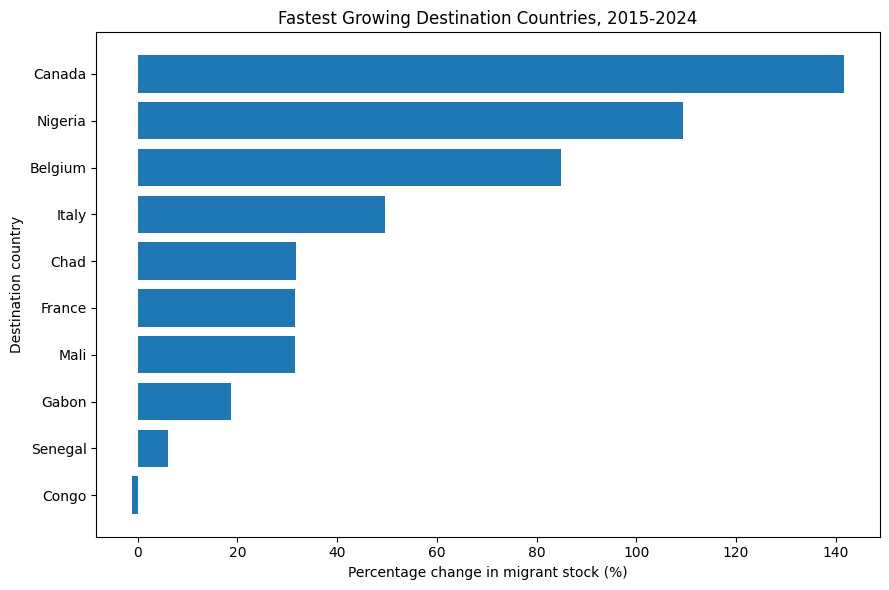

In [15]:
destination_growth = (
    undesa_destinations[undesa_destinations['year'].isin([2015, 2024])]
    .pivot_table(
        index='destination_country',
        columns='year',
        values='value',
        aggfunc='sum'
    )
    .dropna(subset=[2015, 2024])
)

destination_growth['absolute_change_2015_2024'] = (
    destination_growth[2024] - destination_growth[2015]
)

destination_growth['pct_change_2015_2024'] = (
    destination_growth['absolute_change_2015_2024'] / destination_growth[2015] * 100
)

fastest_growing_destinations = (
    destination_growth
    .reset_index()
    .query('`2015` >= 1000')
    .sort_values('pct_change_2015_2024', ascending=False)
    .head(10)
    .sort_values('pct_change_2015_2024')
)

plt.figure(figsize=(9, 6))
plt.barh(
    fastest_growing_destinations['destination_country'],
    fastest_growing_destinations['pct_change_2015_2024']
)

plt.title('Fastest Growing Destination Countries, 2015-2024')
plt.xlabel('Percentage change in migrant stock (%)')
plt.ylabel('Destination country')

save_figure('q1_fastest_growing_destinations_2015_2024.png')

## Q2 - Entry Reason Charts Across Available Years


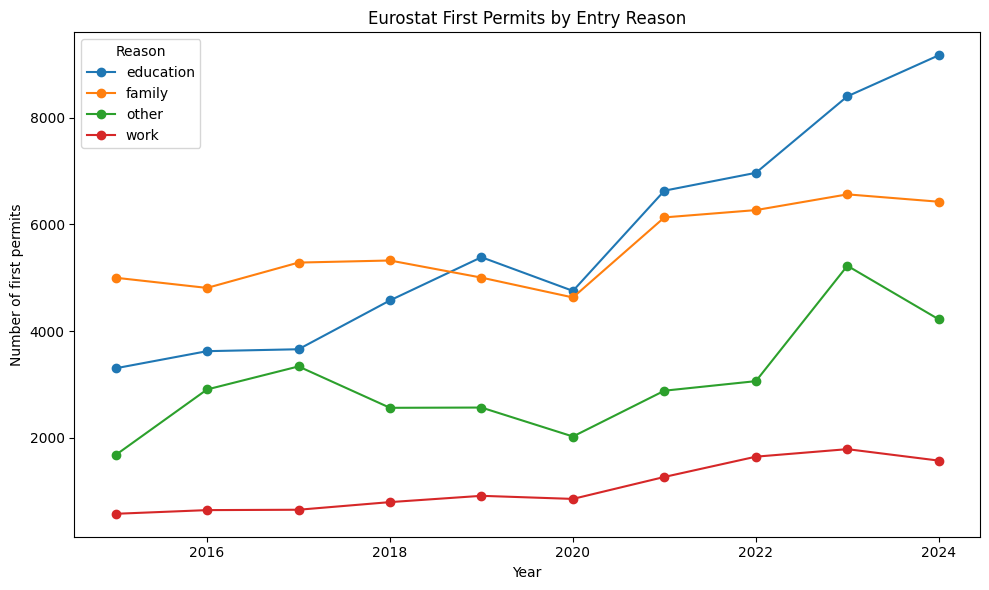

In [8]:
entry_yearly = (
    eurostat_entry.groupby(['year', 'reason'], as_index=False)['value']
    .sum()
    .pivot(index='year', columns='reason', values='value')
    .sort_index()
)

plt.figure(figsize=(10, 6))
for reason in entry_yearly.columns:
    plt.plot(entry_yearly.index, entry_yearly[reason], marker='o', label=reason)
plt.title('Eurostat First Permits by Entry Reason')
plt.xlabel('Year')
plt.ylabel('Number of first permits')
plt.legend(title='Reason')
save_figure('q2_entry_reasons_yearly_evolution.png')


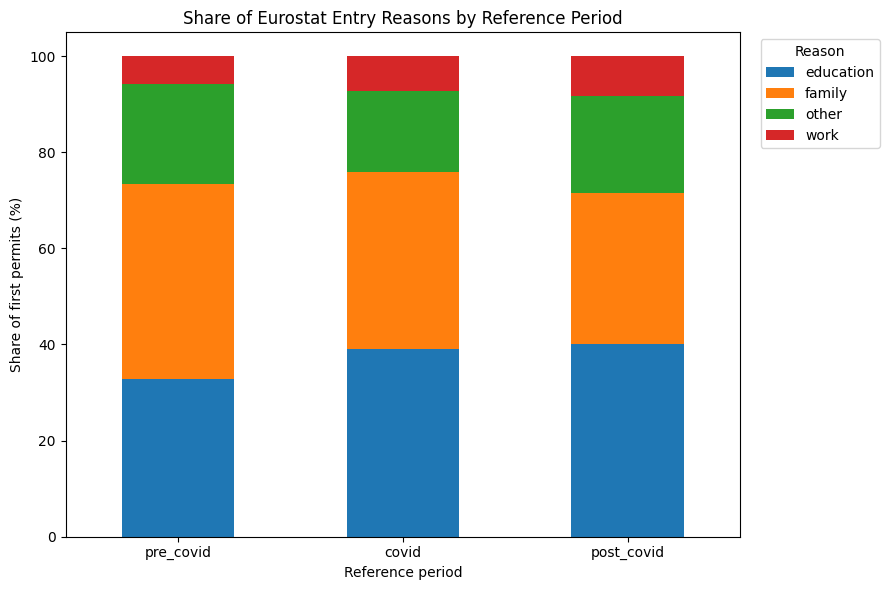

In [9]:
entry_period = eurostat_entry.groupby(['period', 'reason'], as_index=False)['value'].sum()
period_total = entry_period.groupby('period', as_index=False)['value'].sum().rename(columns={'value': 'period_total'})
entry_period = entry_period.merge(period_total, on='period', how='left')
entry_period['share_pct'] = entry_period['value'] / entry_period['period_total'] * 100
entry_share_pivot = (
    entry_period.pivot_table(index='period', columns='reason', values='share_pct', aggfunc='sum')
    .reindex(period_order)
)

plt.figure(figsize=(9, 6))
entry_share_pivot.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Share of Eurostat Entry Reasons by Reference Period')
plt.xlabel('Reference period')
plt.ylabel('Share of first permits (%)')
plt.xticks(rotation=0)
plt.legend(title='Reason', bbox_to_anchor=(1.02, 1), loc='upper left')
save_figure('q2_entry_reasons_share_by_period.png')


## Q3 - Post-Arrival Charts Across Available Years

Q3 visualizations use Eurostat only for the main charts.


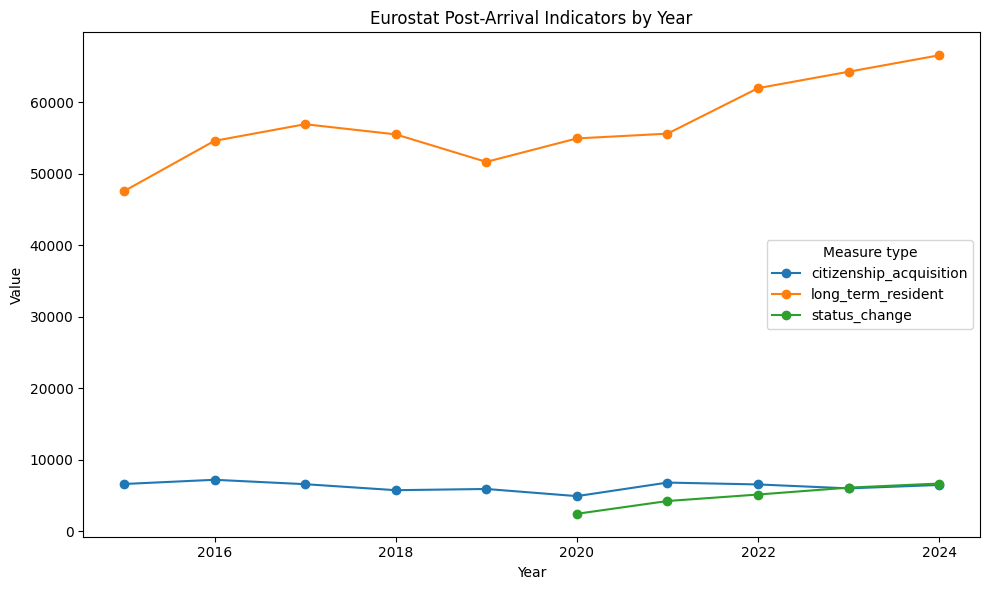

In [10]:
post_yearly = (
    eurostat_post_arrival.groupby(['year', 'measure_type'], as_index=False)['value']
    .sum()
    .pivot(index='year', columns='measure_type', values='value')
    .sort_index()
)

plt.figure(figsize=(10, 6))
for measure_type in post_yearly.columns:
    plt.plot(post_yearly.index, post_yearly[measure_type], marker='o', label=measure_type)
plt.title('Eurostat Post-Arrival Indicators by Year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(title='Measure type')
save_figure('q3_post_arrival_indicators_by_year_eurostat.png')


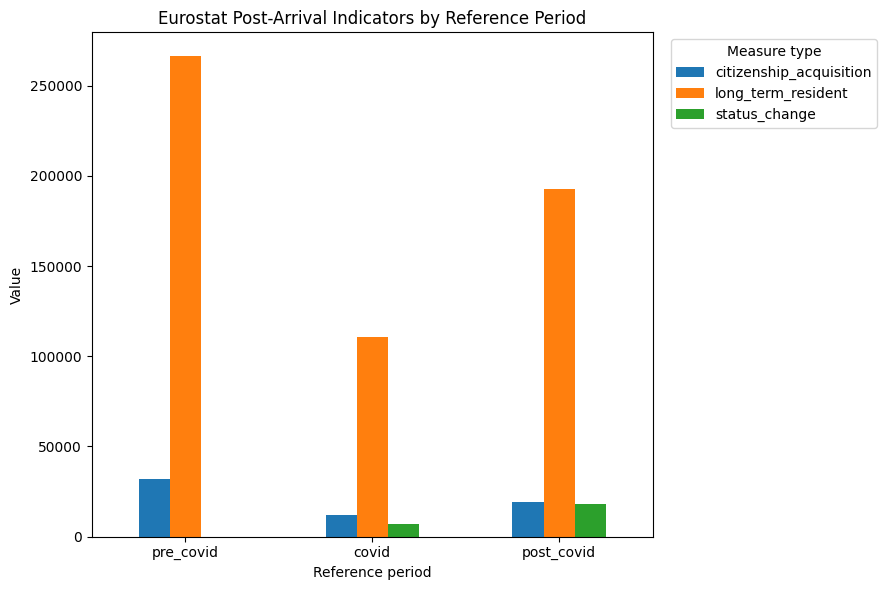

In [11]:
post_period = (
    eurostat_post_arrival.groupby(['period', 'measure_type'], as_index=False)['value']
    .sum()
    .pivot_table(index='period', columns='measure_type', values='value', aggfunc='sum')
    .reindex(period_order)
)

plt.figure(figsize=(9, 6))
post_period.plot(kind='bar', ax=plt.gca())
plt.title('Eurostat Post-Arrival Indicators by Reference Period')
plt.xlabel('Reference period')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.legend(title='Measure type', bbox_to_anchor=(1.02, 1), loc='upper left')
save_figure('q3_post_arrival_indicators_by_period_eurostat.png')


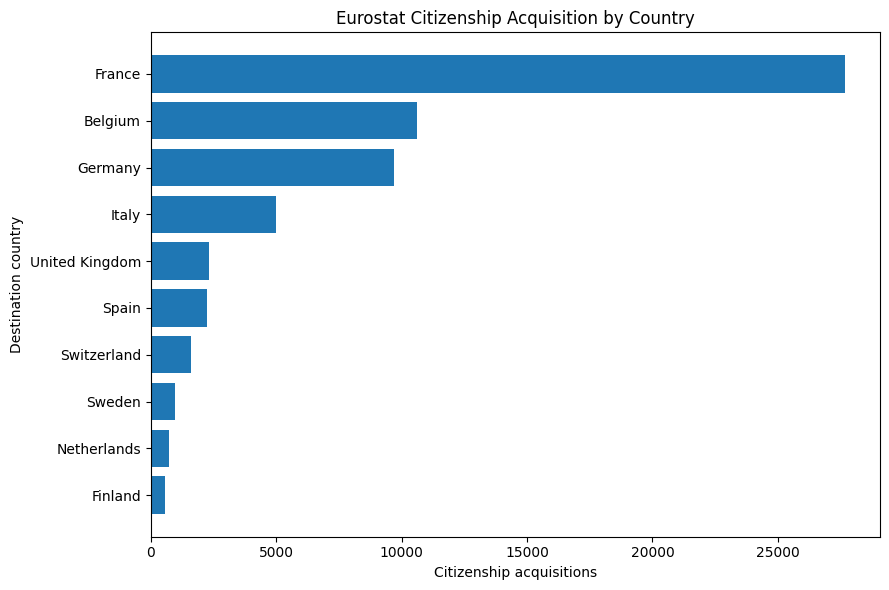

In [12]:
citizenship_country = (
    eurostat_post_arrival[
        eurostat_post_arrival['measure_type'].str.lower() == 'citizenship_acquisition'
    ]
    .groupby('destination_country', as_index=False)['value']
    .sum()
    .sort_values('value', ascending=False)
    .head(10)
    .sort_values('value')
)

plt.figure(figsize=(9, 6))
plt.barh(citizenship_country['destination_country'], citizenship_country['value'])
plt.title('Eurostat Citizenship Acquisition by Country')
plt.xlabel('Citizenship acquisitions')
plt.ylabel('Destination country')
save_figure('q3_citizenship_acquisition_by_country_eurostat.png')


## Export Summary

The notebook saves final PNG figures in `outputs/figures/` with `dpi=300`.
